<a href="https://colab.research.google.com/github/sanjaypras/crispr_pred/blob/main/genome_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
import numpy as np


In [2]:
df = pd.read_csv('V1_suppl_data.txt', sep='\t')

In [3]:
df.head(20)

,Spacer Sequence,Extended Spacer(NNNN[20nt]NGGNNNNNNN),Strand,Transcript,Gene Symbol,Nucleotide cut position,Amino Acid Cut position,Percent Peptide,Annotation,Activity,Percent Rank
0,CTGATCTCCAGATATGACCA,ACAGCTGATCTCCAGATATGACCATGGGTTTGTG,sense,ENSMUST00000182755,CD45,242,2.0,0.18,CDS,2.308903,0.346278
1,TGATCTCCAGATATGACCAT,CAGCTGATCTCCAGATATGACCATGGGTTTGTGG,sense,ENSMUST00000182755,CD45,243,2.0,0.18,CDS,2.530273,0.365696
2,AAGTTTGAGCCACAAACCCA,CCAGAAGTTTGAGCCACAAACCCATGGTCATATC,antisense,ENSMUST00000182755,CD45,248,4.0,0.35,CDS,4.098996,0.857605
3,CAGATATGACCATGGGTTTG,TCTCCAGATATGACCATGGGTTTGTGGCTCAAAC,sense,ENSMUST00000182755,CD45,250,5.0,0.44,CDS,3.807251,0.705502
4,GGGTTTGTGGCTCAAACTTC,CCATGGGTTTGTGGCTCAAACTTCTGGCCTTTGG,sense,ENSMUST00000182755,CD45,263,9.0,0.80,CDS,1.585304,0.258900
5,TGGCTCAAACTTCTGGCCTT,TTTGTGGCTCAAACTTCTGGCCTTTGGATTTGCC,sense,ENSMUST00000182755,CD45,270,11.0,0.97,CDS,-3.768976,0.006472
6,GTCCAGAAGGGCAAATCCAA,CTGTGTCCAGAAGGGCAAATCCAAAGGCCAGAAG,antisense,ENSMUST00000182755,CD45,275,13.0,1.15,CDS,3.816749,0.711974
7,GGCCTTTGGATTTGCCCTTC,TTCTGGCCTTTGGATTTGCCCTTCTGGACACAGA,sense,ENSMUST00000182755,CD45,284,16.0,1.42,CDS,1.247028,0.207120
8,AAAGACTTCTGTGTCCAGAA,TGACAAAGACTTCTGTGTCCAGAAGGGCAAATCC,antisense,ENSMUST00000182755,CD45,287,17.0,1.50,CDS,4.559195,0.996764
9,CAAAGACTTCTGTGTCCAGA,GTGACAAAGACTTCTGTGTCCAGAAGGGCAAATC,antisense,ENSMUST00000182755,CD45,288,17.0,1.50,CDS,3.497215,0.569579


In [4]:
df.describe()

,Nucleotide cut position,Amino Acid Cut position,Percent Peptide,Activity,Percent Rank
count,2144.000000,2135.000000,2135.000000,2144.000000,2144.000000
mean,18711.790578,303.029508,47.334014,1.901516,0.502099
std,30899.375678,250.681202,27.950229,1.903784,0.288742
min,56.000000,2.000000,0.180000,-6.603273,0.002198
25%,1052.750000,114.000000,23.510000,0.572749,0.252667
50%,8555.500000,246.000000,47.610000,1.730833,0.502252
75%,15748.750000,402.000000,69.920000,3.635408,0.751337
max,110815.000000,1130.000000,100.000000,6.305269,1.000000


In [5]:
df = df.drop(columns=['Spacer Sequence', 'Transcript', 'Nucleotide cut position', 'Amino Acid Cut position', 'Annotation'])

In [6]:
df.head()

,Extended Spacer(NNNN[20nt]NGGNNNNNNN),Strand,Gene Symbol,Percent Peptide,Activity,Percent Rank
0,ACAGCTGATCTCCAGATATGACCATGGGTTTGTG,sense,CD45,0.18,2.308903,0.346278
1,CAGCTGATCTCCAGATATGACCATGGGTTTGTGG,sense,CD45,0.18,2.530273,0.365696
2,CCAGAAGTTTGAGCCACAAACCCATGGTCATATC,antisense,CD45,0.35,4.098996,0.857605
3,TCTCCAGATATGACCATGGGTTTGTGGCTCAAAC,sense,CD45,0.44,3.807251,0.705502
4,CCATGGGTTTGTGGCTCAAACTTCTGGCCTTTGG,sense,CD45,0.80,1.585304,0.258900


In [7]:
df['Gene Symbol'].unique()

array(['CD45', 'H2-K', 'CD33', 'THY1', 'CD13', 'CD28', 'CD5', 'CD15',
       'CD43'], dtype=object)

In [8]:
df['Strand'] = df['Strand'].astype(str).str.strip().str.lower()
df['Strand'] = df['Strand'].map({'sense': 1, 'antisense': 0})
df.head()

,Extended Spacer(NNNN[20nt]NGGNNNNNNN),Strand,Gene Symbol,Percent Peptide,Activity,Percent Rank
0,ACAGCTGATCTCCAGATATGACCATGGGTTTGTG,1,CD45,0.18,2.308903,0.346278
1,CAGCTGATCTCCAGATATGACCATGGGTTTGTGG,1,CD45,0.18,2.530273,0.365696
2,CCAGAAGTTTGAGCCACAAACCCATGGTCATATC,0,CD45,0.35,4.098996,0.857605
3,TCTCCAGATATGACCATGGGTTTGTGGCTCAAAC,1,CD45,0.44,3.807251,0.705502
4,CCATGGGTTTGTGGCTCAAACTTCTGGCCTTTGG,1,CD45,0.80,1.585304,0.258900


In [9]:
df.rename(columns={'Extended Spacer(NNNN[20nt]NGGNNNNNNN)': 'Spacer'}, inplace=True)


In [10]:
df.head()

,Spacer,Strand,Gene Symbol,Percent Peptide,Activity,Percent Rank
0,ACAGCTGATCTCCAGATATGACCATGGGTTTGTG,1,CD45,0.18,2.308903,0.346278
1,CAGCTGATCTCCAGATATGACCATGGGTTTGTGG,1,CD45,0.18,2.530273,0.365696
2,CCAGAAGTTTGAGCCACAAACCCATGGTCATATC,0,CD45,0.35,4.098996,0.857605
3,TCTCCAGATATGACCATGGGTTTGTGGCTCAAAC,1,CD45,0.44,3.807251,0.705502
4,CCATGGGTTTGTGGCTCAAACTTCTGGCCTTTGG,1,CD45,0.80,1.585304,0.258900


In [11]:
def prepare_final_dataset(df):
    mapping = {'A': [1,0,0,0], 'C': [0,1,0,0], 'G': [0,0,1,0], 'T': [0,0,0,1]}

    dna_list = []
    for seq in df['Spacer']:
        bits = []
        for base in seq.upper():
            bits.extend(mapping.get(base, [0,0,0,0]))
        dna_list.append(bits)
    X_dna = np.array(dna_list)

    X_extras = df[['Percent Peptide', 'Strand']].values
    X = np.hstack([X_dna, X_extras])
    y = df['Percent Rank'].values
    return X, y, X_dna.shape[1]   # also return dna width

In [12]:
X, y, dna_width = prepare_final_dataset(df)
print(f"X shape: {X.shape}, DNA cols: {dna_width}, Extra cols: {X.shape[1] - dna_width}")

X shape: (2144, 138), DNA cols: 136, Extra cols: 2


In [13]:
n_positions = dna_width // 4   # e.g. 136 // 4 = 34 positions

dna_feature_names = [
    f"DNA Pos {i} ({base})"
    for i in range(n_positions)
    for base in ['A', 'C', 'G', 'T']
]
extra_feature_names = ['Percent Peptide', 'Strand']
feature_names = dna_feature_names + extra_feature_names

assert len(feature_names) == X.shape[1], \
    f"Mismatch: {len(feature_names)} names vs {X.shape[1]} columns"

X_named = pd.DataFrame(X, columns=feature_names)


In [14]:
import numpy as np

# 1. Check the whole matrix
has_nan = np.isnan(X).any()
print(f"Does X have NaNs? {has_nan}")

# 2. Find exactly where they are (if any)
if has_nan:
    nan_cols = np.where(np.isnan(X).any(axis=0))[0]
    print(f"NaNs found in column indices: {nan_cols}")

    # Quick fix: Replace NaNs with 0 (or the mean of the column)
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='mean')
    X = imputer.fit_transform(X)

Does X have NaNs? True
NaNs found in column indices: [136]


In [15]:
from scipy import stats

# We only check the numerical columns (the last 18 features in your case)
# Assuming 120-137 are your numerical/extra features
numerical_X = X[:, 120:]

z_scores = np.abs(stats.zscore(numerical_X))
outliers = np.where(z_scores > 3)

print(f"Number of outlier data points detected: {len(outliers[0])}")

Number of outlier data points detected: 0


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data is now clean, outlier-checked, and scaled!")

Data is now clean, outlier-checked, and scaled!


In [17]:
X_scaled

array([[ 1.90281099, -0.6168904 , -0.58884095, ..., -0.53780695,
        -1.69101899,  1.06060177],
       [-0.52553827,  1.62103349, -0.58884095, ..., -0.53780695,
        -1.69101899,  1.06060177],
       [-0.52553827,  1.62103349, -0.58884095, ..., -0.53780695,
        -1.68492252, -0.94286096],
       ...,
       [-0.52553827,  1.62103349, -0.58884095, ..., -0.53780695,
         1.00792599, -0.94286096],
       [-0.52553827,  1.62103349, -0.58884095, ..., -0.53780695,
         0.17270902, -0.94286096],
       [ 1.90281099, -0.6168904 , -0.58884095, ..., -0.53780695,
        -1.29797572, -0.94286096]])

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import spearmanr

# 1. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Initialize and Train the Basic Model
model = LinearRegression()
model.fit(X_train, y_train)

# 3. Make Predictions
y_pred = model.predict(X_test)

# Since Percent Rank must be between 0 and 1, we clip any "overflow" predictions
y_pred = np.clip(y_pred, 0, 1)

In [19]:
# Calculate Spearman Correlation
spearman_corr, _ = spearmanr(y_test, y_pred)

print(f"--- Model Results ---")
print(f"Spearman Correlation: {spearman_corr:.4f}")
print(f"Mean Absolute Error:  {mean_absolute_error(y_test, y_pred):.4f}")
print(f"R-squared Score:      {r2_score(y_test, y_pred):.4f}")

--- Model Results ---
Spearman Correlation: 0.4262
Mean Absolute Error:  0.2188
R-squared Score:      0.1701


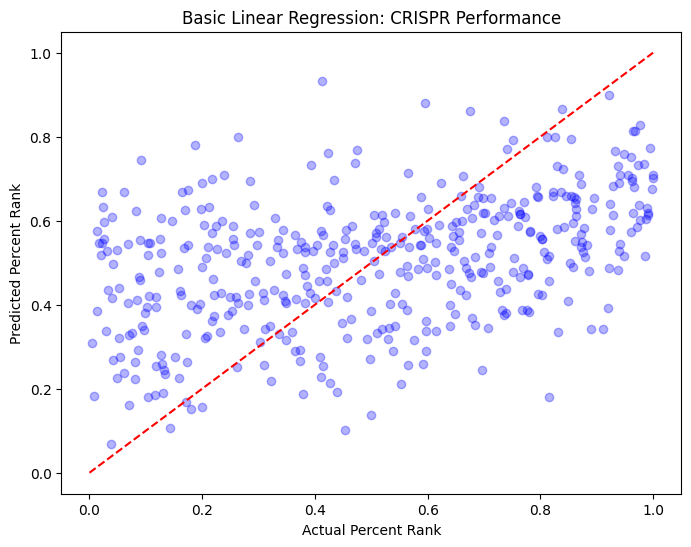

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
plt.plot([0, 1], [0, 1], color='red', linestyle='--') # The "Perfect Prediction" line
plt.xlabel('Actual Percent Rank')
plt.ylabel('Predicted Percent Rank')
plt.title('Basic Linear Regression: CRISPR Performance')
plt.show()

--- LR Model Results ---  
Spearman Correlation: 0.4262  
Mean Absolute Error:  0.2188  
R-squared Score:      0.1701  

thoughts:  
coud be better, but not a bad start;
definielty room to improve  


###lets try xgb

In [21]:
import xgboost as xgb
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    random_state=42
)
xgb_model.fit(X_train, y_train)

# ── 5. Evaluate ───────────────────────────────────────────────────────────────
y_pred = np.clip(xgb_model.predict(X_test), 0, 1)
spearman, _ = spearmanr(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"\n--- XGBoost Results ---")
print(f"Spearman Correlation: {spearman:.4f}")
print(f"Mean Absolute Error:  {mae:.4f}")


--- XGBoost Results ---
Spearman Correlation: 0.5750
Mean Absolute Error:  0.1934


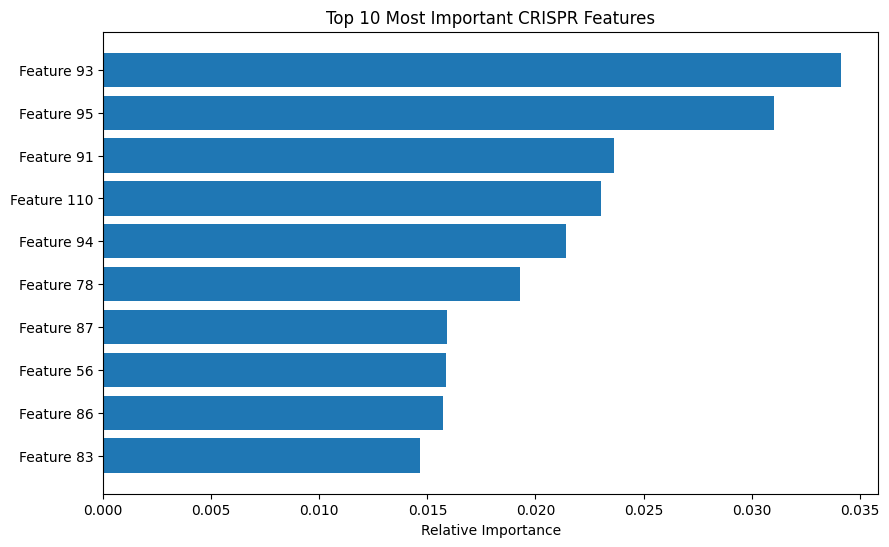

In [22]:
import matplotlib.pyplot as plt

# Get the top 10 most important features
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[-10:] # Top 10

plt.figure(figsize=(10, 6))
plt.title("Top 10 Most Important CRISPR Features")
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [f"Feature {i}" for i in indices])
plt.xlabel("Relative Importance")
plt.show()

In [23]:
# If you used the hstack method:
# 0-119 are DNA bits.
# 120+ are your numerical columns.

def get_feature_name(index):
    if index < 120:
        pos = index // 4
        base = ['A', 'C', 'G', 'T'][index % 4]
        return f"DNA Pos {pos} (Base {base})"
    else:
        # Check the order of your extra_features list
        extras = ['Percent Peptide', 'Strand', 'Cut Position', ...]
        return extras[index - 120]

print(f"Feature 93 is: {get_feature_name(93)}")

Feature 93 is: DNA Pos 23 (Base C)


--- XGBoost Model Results ---  
Spearman Correlation: 0.5750  
Mean Absolute Error:  0.1934

thoughts:  
better thean lr(expected)  
still room to improve  

##lets try nn now

In [41]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks
from scipy.stats import spearmanr
import numpy as np

# 1. Define the Architecture
# Removed redundant input_shape from hidden layers for clarity
model = models.Sequential([
    layers.Dense(256, kernel_regularizer=regularizers.l2(0.01), input_shape=(X_train.shape[1],)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.4),

    layers.Dense(256, kernel_regularizer=regularizers.l2(0.01)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.4),

    layers.Dense(128, kernel_regularizer=regularizers.l2(0.01)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.4),

    layers.Dense(64, kernel_regularizer=regularizers.l2(0.01)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.4),

    layers.Dense(32),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Dense(1, activation='sigmoid')
])

# Custom Callback for Spearman Correlation
class SpearmanMetrics(tf.keras.callbacks.Callback):
    def __init__(self, validation_data):
        super().__init__()
        self.x_val, self.y_val = validation_data

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        y_pred = self.model.predict(self.x_val, verbose=0)
        coef, _ = spearmanr(self.y_val.flatten(), y_pred.flatten())
        logs["val_spearman"] = coef
        print(f" - val_spearman: {coef:.4f}")

# 2. Compile with Adagrad
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

# 3. Setup Callbacks
# ReduceLROnPlateau replaces your manual loop
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,         # Multiply LR by 0.5 when triggered
    patience=10,        # Wait 10 epochs with no Spearman improvement
    min_lr=0.0001,      # Lower bound for learning rate
    mode='max',
    verbose=1
)

early_stop = callbacks.EarlyStopping(
    monitor='val_spearman',
    mode='max',
    patience=20,
    restore_best_weights=True
)

# 4. Train
# Pass the data directly; no loop required
history = model.fit(
    X_train, y_train,
    epochs=200,         # Increased epochs as ReduceLR handles the reduction automatically
    batch_size=32,
    validation_split=0.2,
    callbacks=[SpearmanMetrics(validation_data=(X_test, y_test)), reduce_lr, early_stop],
    verbose=1
)

# 5. Final Evaluation
y_pred_nn = model.predict(X_test).flatten()
spearman_final, _ = spearmanr(y_test, y_pred_nn)

print(f"\n--- Final Results ---")
print(f"Final Spearman Correlation: {spearman_final:.4f}")

Epoch 1/200
41/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.4770 - mae: 0.2804 - val_spearman: 0.1449
43/43 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 5.9519 - mae: 0.2762 - val_loss: 4.9695 - val_mae: 0.2516 - val_spearman: 0.1449 - learning_rate: 5.0000e-04
Epoch 2/200
41/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.6212 - mae: 0.2663 - val_spearman: 0.1683
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.2513 - mae: 0.2603 - val_loss: 3.5489 - val_mae: 0.2404 - val_spearman: 0.1683 - learning_rate: 5.0000e-04
Epoch 3/200
41/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.3075 - mae: 0.2549 - val_spearman: 0.2404
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.0491 - mae: 0.2559 - val_loss: 2.5541 - val_mae: 0.2441 - val_spearman: 0.2404 - learning_rate: 5.0000e-04
Epoch 4/200
40/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.3920 - mae: 0.2594 - val_spearman: 0.3317
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.2045 - mae: 0.2561 - val_loss: 1.8534 - val_mae: 0.2475 - val_spear

with a 256, 128, 64, 16, we got 0.55  
with a 256, 128, 128, 64, 16, we got 0.5  
with a 256, 128, 64, 32, 16, we got 0.52  
with a 512, 256, 64, 32, 16, we got .52   
with 512, 128, 32, 32, 16, we got 0.5  
with a 256, 256, 128, 64, 32, we got 0.54

with 256, 256, 128, 64, 32, we got 0.53(rmsprop)

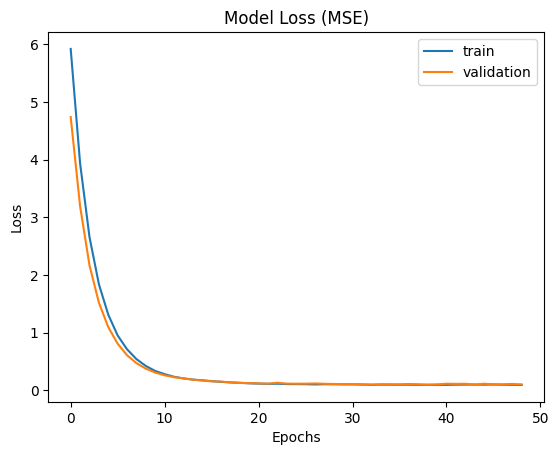

In [48]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.title('Model Loss (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

--- Improved Neural Network Results ---  
Spearman Correlation: 0.5124

thoughts:  
nn didnt have enough data to run well  
xgboost was the best, so lets try and run shap on the xgb model

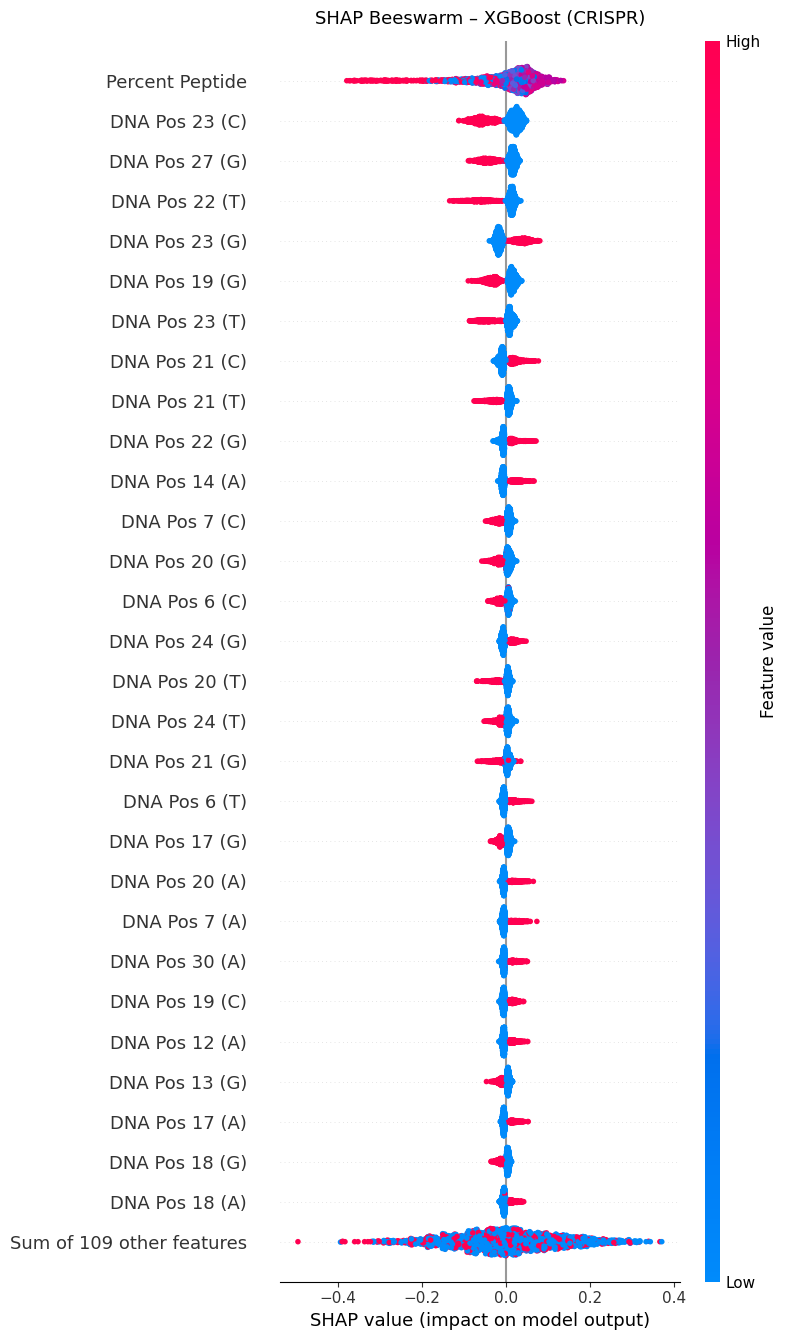

In [61]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

# Wrap X in a named DataFrame
n_positions = 34
dna_feature_names = [
    f"DNA Pos {i} ({base})"
    for i in range(n_positions)
    for base in ['A', 'C', 'G', 'T']
]
feature_names = dna_feature_names + ['Percent Peptide', 'Strand']

X_named = pd.DataFrame(X, columns=feature_names)

# SHAP
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_named)

# Plot
plt.figure()
shap.plots.beeswarm(shap_values, max_display=30, show=False)
plt.title("SHAP Beeswarm – XGBoost (CRISPR)", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig("shap_beeswarm_xgb.png", dpi=150, bbox_inches="tight")
plt.show()

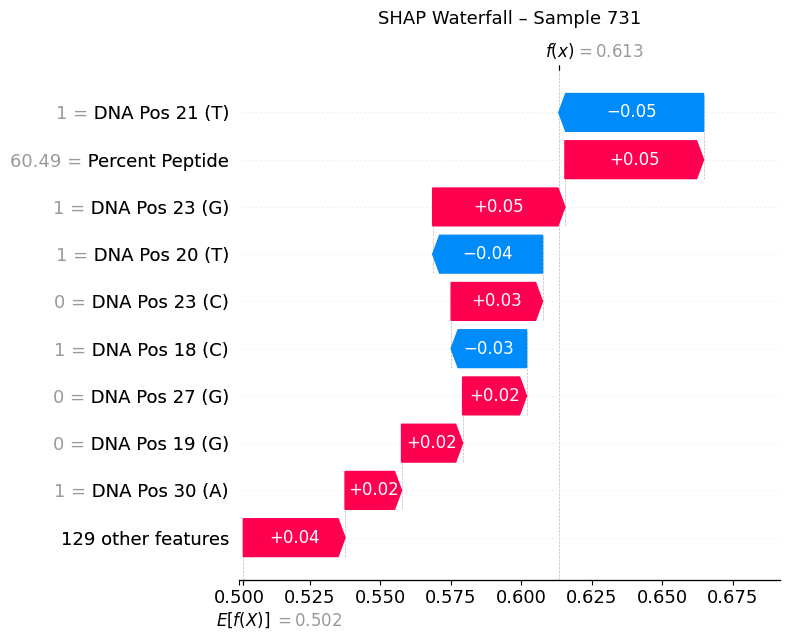

Saved → waterfall_sample_731.png


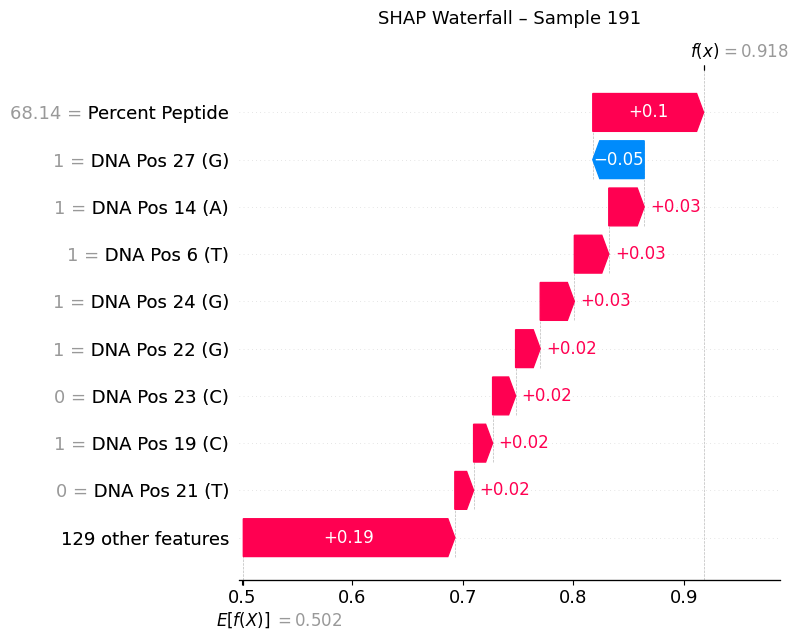

Saved → waterfall_sample_191.png


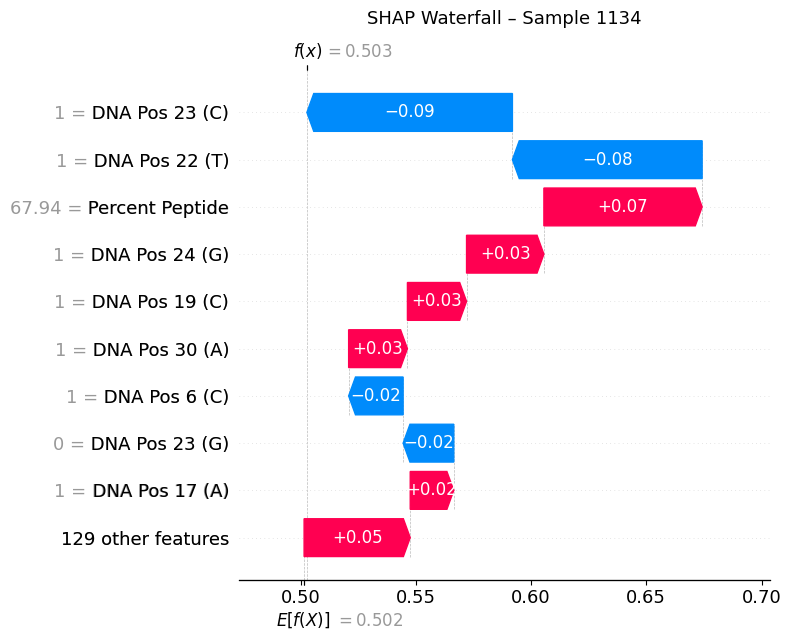

Saved → waterfall_sample_1134.png


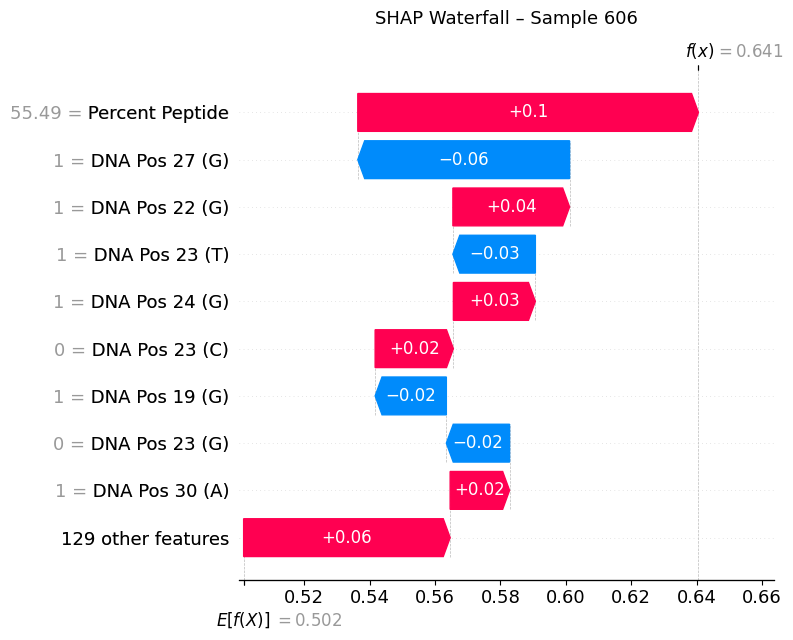

Saved → waterfall_sample_606.png


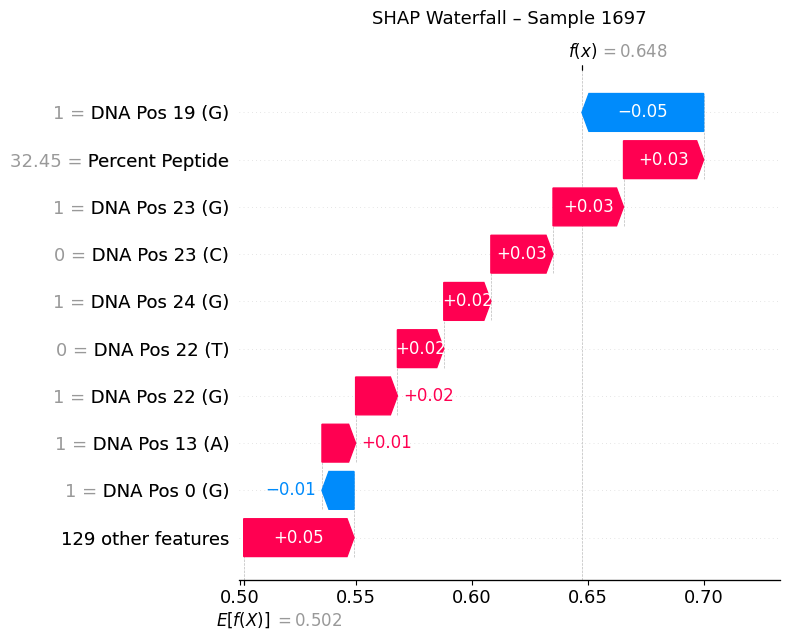

Saved → waterfall_sample_1697.png


In [62]:
import random

# Pick a few random samples
sample_indices = random.sample(range(len(X_named)), 5)  # change 5 to however many you want

for idx in sample_indices:
    plt.figure()
    shap.plots.waterfall(shap_values[idx], show=False)
    plt.title(f"SHAP Waterfall – Sample {idx}", fontsize=13, pad=12)
    plt.tight_layout()
    plt.savefig(f"waterfall_sample_{idx}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → waterfall_sample_{idx}.png")